In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('quora.csv')
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
df['is_duplicate'].value_counts()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [4]:
df.tail()

,id,qid1,qid2,question1,question2,is_duplicate
404285,404285,433578,379845,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404286,404286,18840,155606,Do you believe there is life after death?,Is it true that there is life after death?,1
404287,404287,537928,537929,What is one coin?,What's this coin?,0
404288,404288,537930,537931,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0
404289,404289,537932,537933,What is like to have sex with cousin?,What is it like to have sex with your cousin?,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(404290, 6)

In [8]:
ndf = df.sample(30000, random_state=2)
ndf.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [9]:
def preprocess(q):
    
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q

In [10]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [11]:
ndf['question1'] = ndf['question1'].apply(preprocess)
ndf['question2'] = ndf['question2'].apply(preprocess)

In [12]:
ndf.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


In [13]:
ndf['q1len'] = ndf['question1'].str.len()
ndf['q2len'] = ndf['question2'].str.len()

In [14]:
ndf['q1num_words'] = ndf['question1'].apply(lambda row : len(row.split(" ")))
ndf['q2num_words'] = ndf['question2'].apply(lambda row : len(row.split(" ")))

In [15]:
def common_words(row):
    w1 = set(map(lambda word : word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word : word.lower().strip(), row['question2'].split(" ")))

    return len(w1 & w2)

In [16]:
ndf['word_common'] = ndf.apply(common_words, axis=1)

In [17]:
def total_words(row):
    w1 = set(map(lambda word : word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word : word.lower().strip(), row['question2'].split(" ")))

    return (len(w1) + len(w2))

In [18]:
ndf['word_total'] = ndf.apply(total_words, axis=1)

In [19]:
ndf['word_share'] = round(ndf['word_common'] / ndf['word_total'], 2)

In [20]:
ndf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1len,q2len,q1num_words,q2num_words,word_common,word_total,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,8,24,0.33
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,4,38,0.11
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,1,34,0.03
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.23


In [21]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SANSKAR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
# Advanced features
from nltk.corpus import stopwords

def fetch_token_features(row):
    q1 = row['question1']
    q2 = row['question2']

    safe = 0.0001
    stop = stopwords.words('english')
    tokfeat = [0.0]*8

    # Converting the sentence into tokens
    q1tokens = q1.split()
    q2tokens = q2.split()

    if len(q1tokens) == 0 or len(q2tokens) == 0:
        return tokfeat

    # Get the non stopwords in questions
    q1words = set([word for word in q1tokens if word not in stop])
    q2words = set([word for word in q2tokens if word not in stop])

    # Get the stopwords in questions
    q1stops = set([word for word in q1tokens if word in stop])
    q2stops = set([word for word in q2tokens if word in stop])

    # Get the common non stop words from question pair
    common_word_count = len(q1words.intersection(q2words))

    # Get the common stop words from question pair
    common_stop_count = len(q1stops.intersection(q2stops))

    # Get the common tokens from question pair
    common_token_count = len(set(q1tokens).intersection(set(q2tokens)))

    tokfeat[0] = common_word_count / (min(len(q1words), len(q2words)) + safe)
    tokfeat[1] = common_word_count / (max(len(q1words), len(q2words)) + safe)
    tokfeat[2] = common_stop_count / (min(len(q1stops), len(q2stops)) + safe)
    tokfeat[3] = common_stop_count / (max(len(q1stops), len(q2stops)) + safe)
    tokfeat[4] = common_token_count / (min(len(q1tokens), len(q2tokens)) + safe)
    tokfeat[5] = common_token_count / (max(len(q1tokens), len(q2tokens)) + safe)

    # Last word of both question is same or not
    tokfeat[6] = int(q1tokens[-1] == q2tokens[-1])

    # First word of both question is same or not
    tokfeat[7] = int(q1tokens[0] == q2tokens[0])

    return tokfeat

In [23]:
tokfeat = ndf.apply(fetch_token_features, axis=1)

ndf['cwc_min'] = list(map(lambda x : x[0], tokfeat))
ndf['cwc_max'] = list(map(lambda x : x[1], tokfeat))
ndf['csc_min'] = list(map(lambda x : x[2], tokfeat))
ndf['csc_max'] = list(map(lambda x : x[3], tokfeat))
ndf['ctc_min'] = list(map(lambda x : x[4], tokfeat))
ndf['ctc_max'] = list(map(lambda x : x[5], tokfeat))
ndf['last_word_eq'] = list(map(lambda x : x[6], tokfeat))
ndf['first_word_eq'] = list(map(lambda x : x[7], tokfeat))

In [24]:
ndf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1len,q2len,q1num_words,q2num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874989,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,24,0.33,0.666644,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,38,0.11,0.000000,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,34,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.23,0.749981,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0


In [25]:
import distance

def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']

    lenfeat = [0.0]*3

    # Converting the sentence into tokens
    q1tokens = q1.split()
    q2tokens = q2.split()

    if len(q1tokens) == 0 or len(q2tokens) == 0:
        return lenfeat

    # Absolute length features
    lenfeat[0] = abs(len(q1tokens) - len(q2tokens))

    # Average token length of both qustions
    lenfeat[1] = (len(q1tokens) + len(q2tokens)) / 2

    strs = list(distance.lcsubstrings(q1, q2))
    lenfeat[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return lenfeat

In [26]:
lenfeat = ndf.apply(fetch_length_features, axis=1)

ndf['abs_len_diff'] = list(map(lambda x : x[0], lenfeat))
ndf['mean_len'] = list(map(lambda x : x[1], lenfeat))
ndf['longest_substr_ratio'] = list(map(lambda x : x[2], lenfeat))

In [27]:
ndf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1len,q2len,q1num_words,q2num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0,3.0,13.5,0.224490
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0,6.0,23.0,0.047619
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.050847
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0,4.0,7.0,0.542857


In [28]:
# Fuzzy features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    q1 = row['question1']
    q2 = row['question2']

    fuzzfeat = [0.0]*4

    # fuzz ratio
    fuzzfeat[0] = fuzz.QRatio(q1, q2)

    # fuzz partial ratio
    fuzzfeat[1] = fuzz.partial_ratio(q1, q2)

    # token sort ratio
    fuzzfeat[2] = fuzz.token_sort_ratio(q1, q2)

    # token set ratio
    fuzzfeat[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzfeat

In [29]:
fuzzfeat = ndf.apply(fetch_fuzzy_features, axis=1)

ndf['fuzz_ratio'] = list(map(lambda x : x[0], fuzzfeat))
ndf['fuzz_partial_ratio'] = list(map(lambda x : x[1], fuzzfeat))
ndf['token_sort_ratio'] = list(map(lambda x : x[2], fuzzfeat))
ndf['token_set_ratio'] = list(map(lambda x : x[3], fuzzfeat))

In [30]:
ndf.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1len,q2len,q1num_words,q2num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0,48,56,13,16,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,327711,454161,454162,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0,104,119,28,21,...,0.115384,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,367788,498109,491396,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0,58,145,14,32,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [31]:
ndf.shape

(30000, 28)

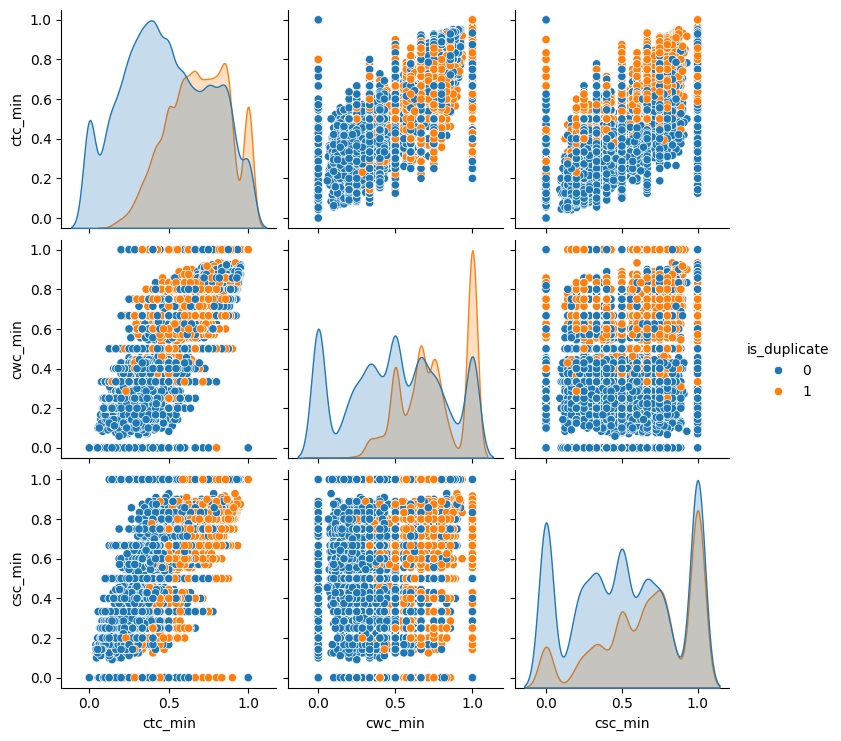

In [32]:
sns.pairplot(ndf[['ctc_min','cwc_min','csc_min','is_duplicate']], hue='is_duplicate')
plt.show()

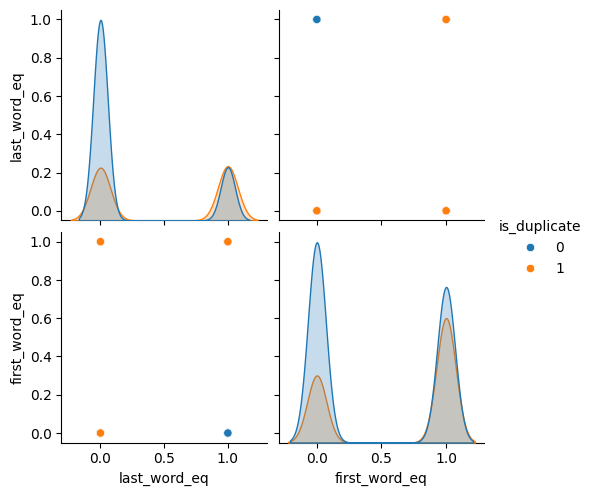

In [33]:
sns.pairplot(ndf[['last_word_eq', 'first_word_eq', 'is_duplicate']], hue='is_duplicate')
plt.show()

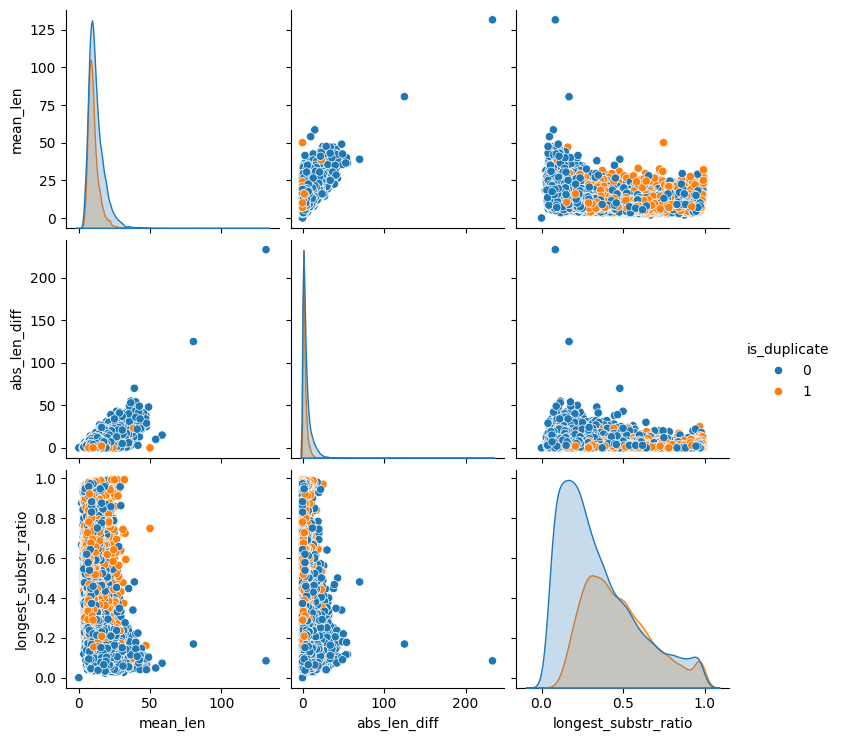

In [34]:
sns.pairplot(ndf[['mean_len','abs_len_diff','longest_substr_ratio','is_duplicate']], hue='is_duplicate')
plt.show()

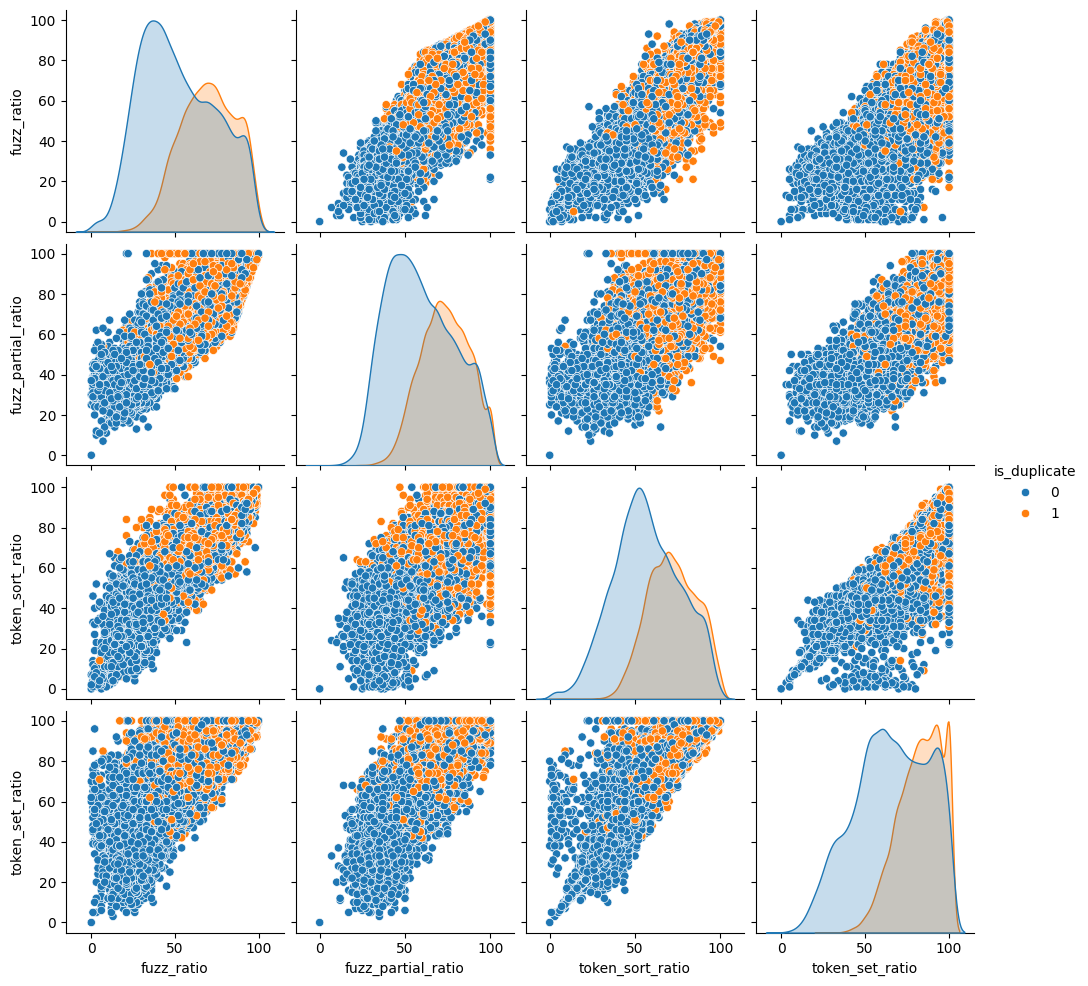

In [35]:
sns.pairplot(ndf[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio',
                  'is_duplicate']],hue='is_duplicate')
plt.show()

In [36]:
ndf.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate', 'q1len',
       'q2len', 'q1num_words', 'q2num_words', 'word_common', 'word_total',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'last_word_eq', 'first_word_eq', 'abs_len_diff', 'mean_len',
       'longest_substr_ratio', 'fuzz_ratio', 'fuzz_partial_ratio',
       'token_sort_ratio', 'token_set_ratio'],
      dtype='object')

In [37]:
# Using TSNE for Dimentionality reduction for 15 Features(Generated after cleaning the data) to 3 dimention

from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

x = mms.fit_transform(ndf[['cwc_min','cwc_max','csc_min','csc_max','ctc_min','ctc_max','last_word_eq',
                           'first_word_eq','abs_len_diff','mean_len','token_set_ratio','token_sort_ratio',
                           'fuzz_ratio','fuzz_partial_ratio','longest_substr_ratio']])
y = ndf['is_duplicate'].values

In [38]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    max_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.147s...
[t-SNE] Computed neighbors for 30000 samples in 10.877s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sa

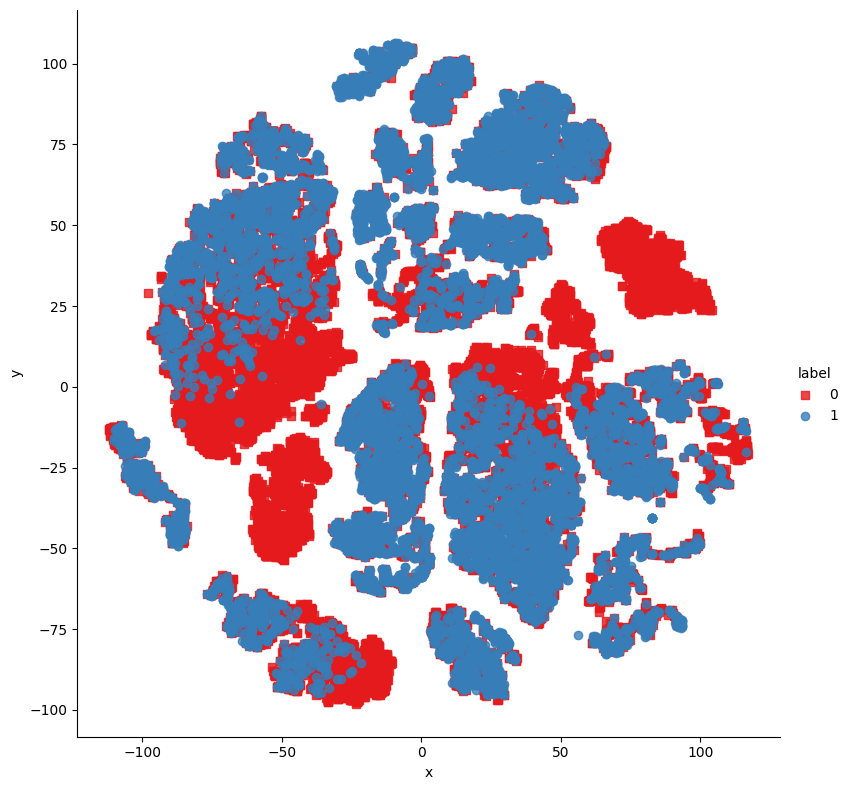

In [39]:
xdf = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=xdf,x='x',y='y',hue='label',fit_reg=False,height=8,palette="Set1",markers=['s','o'])
plt.show()

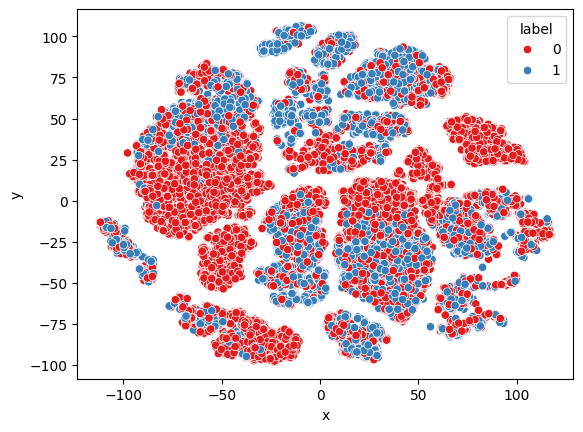

In [40]:
sns.scatterplot(data=xdf, x='x' ,y='y' ,hue='label' ,palette="Set1")
plt.show()

In [41]:
tsne3d = TSNE(
    n_components=3,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    max_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.187s...
[t-SNE] Computed neighbors for 30000 samples in 7.808s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [42]:
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py
py.init_notebook_mode(connected=True)

trace1 = go.Scatter3d(
    x=tsne3d[:,0],
    y=tsne3d[:,1],
    z=tsne3d[:,2],
    mode='markers',
    marker=dict(
        sizemode='diameter',
        color = y,
        colorscale = 'Portland',
        colorbar = dict(title = 'duplicate'),
        line=dict(color='rgb(255, 255, 255)'),
        opacity=0.75
    )
)

data=[trace1]
layout=dict(height=800, width=800, title='3d embedding with engineered features')
fig=dict(data=data, layout=layout)
py.iplot(fig, filename='3DBubble')

In [43]:
qdf = ndf[['question1','question2']]
qdf.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...
327711,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [44]:
fdf = ndf.drop(columns=['id','qid1','qid2','question1','question2',])
fdf.head()

,is_duplicate,q1len,q2len,q1num_words,q2num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,0,48,56,13,16,8,24,0.33,0.666644,0.499988,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69,67,65,74
327711,0,104,119,28,21,4,38,0.11,0.000000,0.000000,...,0.115384,0.0,0.0,6.0,23.0,0.047619,26,29,34,43
367788,0,58,145,14,32,1,34,0.03,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.050847,29,41,23,30
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [45]:
fdf.shape

(30000, 23)

In [46]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=3000)

ques = list(qdf['question1']) + list(qdf['question2'])

q1arr, q2arr = np.vsplit(cv.fit_transform(ques).toarray(), 2)

In [47]:
tdf1 = pd.DataFrame(q1arr, index=qdf.index)
tdf2 = pd.DataFrame(q2arr, index=qdf.index)

tdf = pd.concat([tdf1,tdf2], axis=1)
tdf.shape

(30000, 6000)

In [48]:
fdf = pd.concat([fdf,tdf], axis=1)
fdf.head()

,is_duplicate,q1len,q2len,q1num_words,q2num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0,0,0,0,0,0,0,0,0,0
115086,0,48,56,13,16,8,24,0.33,0.666644,0.499988,...,0,0,0,0,0,0,0,0,0,0
327711,0,104,119,28,21,4,38,0.11,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
367788,0,58,145,14,32,1,34,0.03,0.000000,0.000000,...,0,0,0,1,0,0,0,0,0,0
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [49]:
fdf.shape

(30000, 6023)

In [50]:
x = fdf.iloc[:,1:].values
y = fdf.iloc[:,0].values

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [54]:
y_pred = rf.predict(x_test)

In [55]:
accuracy_score(y_test, y_pred)*100

78.56666666666666

In [57]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [58]:
y_pred1 = xgb.predict(x_test)

In [59]:
accuracy_score(y_test, y_pred1)*100

79.16666666666666

In [60]:
from sklearn.metrics import confusion_matrix

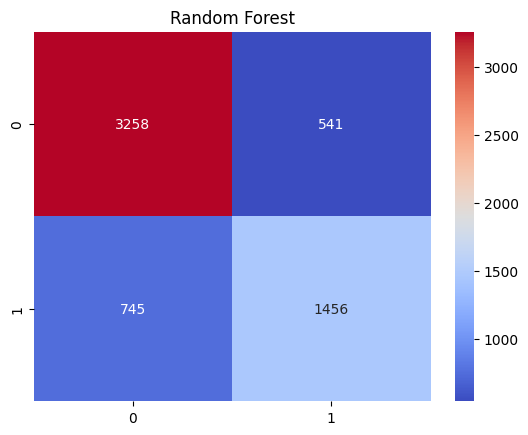

In [65]:
# For random forest
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='0.0f', cmap='coolwarm')
plt.title('Random Forest')
plt.show()

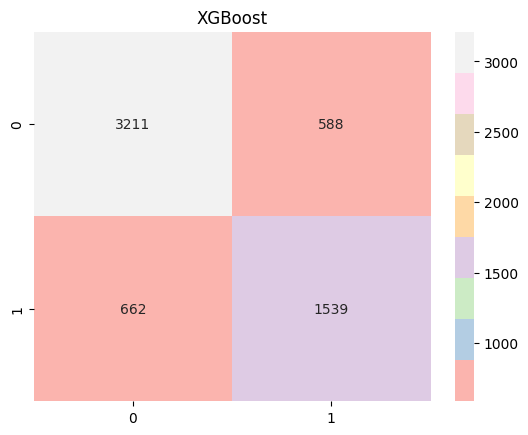

In [68]:
# For xgboost
cm1 = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm1, annot=True, fmt='0.0f', cmap='Pastel1')
plt.title('XGBoost')
plt.show()

In [89]:
def test_common_words(q1, q2):
    w1 = set(map(lambda word : word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word : word.lower().strip(), q2.split(" ")))

    return len(w1 & w2)

In [90]:
def test_total_words(q1, q2):
    w1 = set(map(lambda word : word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word : word.lower().strip(), q2.split(" ")))

    return (len(w1) + len(w2))

In [91]:
def test_fetch_token_features(q1, q2):
    safe = 0.0001
    stop = stopwords.words('english')

    tokfeat = [0.0]*8

    # Converting the sentence into tokens
    q1tokens = q1.split()
    q2tokens = q2.split()

    if len(q1tokens) == 0 or len(q2tokens) == 0:
        return tokfeat

    # Get the non stopwords in questions
    q1words = set([word for word in q1tokens if word not in stop])
    q2words = set([word for word in q2tokens if word not in stop])

    # Get the stopwords in questions
    q1stops = set([word for word in q1tokens if word in stop])
    q2stops = set([word for word in q2tokens if word in stop])

    # Get the common non stopwords from question pair
    common_word_count = len(q1words.intersection(q2words))

    # Get the common stopwords from question pair
    common_stop_count = len(q1stops.intersection(q2stops))

    # Get the common tokens from question pair
    common_token_count = len(set(q1tokens).intersection(set(q2tokens)))

    tokfeat[0] = common_word_count / (min(len(q1words), len(q2words)) + safe)
    tokfeat[1] = common_word_count / (max(len(q1words), len(q2words)) + safe)
    tokfeat[2] = common_stop_count / (min(len(q1stops), len(q2stops)) + safe)
    tokfeat[3] = common_stop_count / (max(len(q1stops), len(q2stops)) + safe)
    tokfeat[4] = common_token_count / (min(len(q1tokens), len(q2tokens)) + safe)
    tokfeat[5] = common_token_count / (max(len(q1tokens), len(q2tokens)) + safe)

    # Last word of both questions is same or not
    tokfeat[6] = int(q1tokens[-1] == q2tokens[-1])

    # Forst word of both questions is same or not
    tokfeat[7] = int(q1tokens[0] == q2tokens[0])

    return tokfeat

In [92]:
def test_fetch_length_features(q1, q2):
    lenfeat = [0.0]*3

    # COnverting the sentence into tokens
    q1tokens = q1.split()
    q2tokens = q2.split()

    if len(q1tokens) == 0 or len(q2tokens) == 0:
        return lenfeat

    # Absolute length features
    lenfeat[0] = abs(len(q1tokens) - len(q2tokens))

    # Average length features
    lenfeat[1] = (len(q1tokens) + len(q2tokens)) / 2

    strs = list(distance.lcsubstrings(q1, q2))
    lenfeat[2] = len(strs[0]) / (min(len(q1), len(q1)) + 1)

    return lenfeat

In [93]:
def test_fetch_fuzzy_features(q1, q2):
    fuzfeat = [0.0]*4

    # fuzz ratio
    fuzfeat[0] = fuzz.QRatio(q1, q2)

    # fuzz partial ratio
    fuzfeat[1] = fuzz.partial_ratio(q1, q2)

    # token sort ratio
    fuzfeat[2] = fuzz.token_sort_ratio(q1, q2)

    # token set ratio
    fuzfeat[3] = fuzz.token_set_ratio(q1, q2)

    return fuzfeat

In [100]:
def query_point_creator(q1, q2):
    ip = []

    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # fetch basic features
    ip.append(len(q1))
    ip.append(len(q2))

    ip.append(len(q1.split(" ")))
    ip.append(len(q2.split(" ")))

    ip.append(test_common_words(q1, q2))
    ip.append(test_total_words(q1, q2))
    ip.append(round(test_common_words(q1,q2) / test_total_words(q1,q2), 2))

    # Fetch token features
    tokfeat = test_fetch_token_features(q1, q2)
    ip.extend(tokfeat)

    # Fetch length features
    lenfeat = test_fetch_length_features(q1, q2)
    ip.extend(lenfeat)

    # Fetch fuzz features
    fuzfeat = test_fetch_fuzzy_features(q1, q2)
    ip.extend(fuzfeat)

    # bow features for q1
    q1bow = cv.transform([q1]).toarray()

    # bow features for q2
    q2bow = cv.transform([q2]).toarray()

    return np.hstack((np.array(ip).reshape(1,22), q1bow, q2bow))

In [101]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Which city serves as the capital of India?'
q4 = 'What is the business capital of India?'

In [102]:
rf.predict(query_point_creator(q1,q4))

array([1])

In [105]:
import pickle

pickle.dump(rf, open('model.pkl','wb'))
pickle.dump(cv ,open('cv.pkl','wb'))